# 06 - Pipeline `cnn-finetune` (two-stage transfer learning)

Fine-tune an ImageNet-pretrained backbone at **224px** with a new 1-logit head. **Two stages:** (1) freeze the backbone, train the head; (2) unfreeze and fine-tune with **discriminative (layer-wise) learning rates** + cosine, plus **EMA**.

We fine-tune **both `efficientnet_b0` and `resnet50`** — set `BACKBONE` below and run the whole notebook once per backbone (artifacts are saved per-backbone). Start with `efficientnet_b0`.

**Sections:** 0 Setup · 1 Data · 2 Model · 3 Stage 1 (head) · 4 Stage 2 (discriminative fine-tune) · 5 Curves · 6 In-distribution evaluation · 7 Cross-generator (OOD) preview · 8 Grad-CAM · 9 Save metrics.

Requires `03_split_and_preprocessing`. Artifacts → `notebooks/artifacts/cnn-finetune/{models,figures,metrics}` (filenames suffixed by backbone).

## 0 - Setup

Pick the backbone. Re-run the notebook with the other value to train both.

In [1]:
import sys, time, json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display

_here = Path.cwd()
_nb_dir = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from utils import datasets as D, models as M, training as T, metrics as Me, viz as V, explain as E, eda
from utils.paths import repo_paths, artifact_dirs

torch.manual_seed(42); np.random.seed(42)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATHS = repo_paths(_nb_dir)
DATA_DIR = PATHS["data"]
AIR_DIR = DATA_DIR / "ai-real-images"
SPLIT_PATH = AIR_DIR / "manifest_split.csv"
TINY_MANIFEST = DATA_DIR / "tiny-genimage" / "manifest_clean.csv"

PIPELINE = "cnn-finetune"
BACKBONE = "efficientnet_b0"        # <-- set to "resnet50" and re-run to train the other
WORKING_SIZE = 224
NORM = "imagenet"
BATCH_SIZE = 128 if BACKBONE == "efficientnet_b0" else 96
STAGE1_EPOCHS = 3
STAGE2_EPOCHS = 12
LABEL_SMOOTH = 0.05
NUM_WORKERS = 8
dirs = artifact_dirs(PIPELINE)
print("device:", device, "| pipeline:", PIPELINE, "| backbone:", BACKBONE, "| batch:", BATCH_SIZE)

device: cuda | pipeline: cnn-finetune | backbone: efficientnet_b0 | batch: 128


## 1 - Data

224px loaders with **ImageNet** normalization (the backbone expects it).

In [2]:
loaders = D.make_loaders(SPLIT_PATH, working_size=WORKING_SIZE, batch_size=BATCH_SIZE,
                         num_workers=NUM_WORKERS, norm=NORM)
train_loader, val_loader, test_loader = loaders["train"], loaders["val"], loaders["test"]
mean, std = D.resolve_stats(NORM, AIR_DIR)
split_df = pd.read_csv(SPLIT_PATH); split_df = split_df[split_df["keep"]]
test_df = split_df[split_df["split_final"] == "test"].reset_index(drop=True)
print(f"train {len(train_loader.dataset):,} | val {len(val_loader.dataset):,} | test {len(test_loader.dataset):,}")

train 43,127 | val 4,792 | test 11,963


## 2 - Model

timm backbone, ImageNet-pretrained, with `num_classes=1` (GAP → dropout → Linear head).

In [3]:
model = M.build_cnn_finetune(BACKBONE, pretrained=True, p_drop=0.3).to(device, memory_format=torch.channels_last)
print("total params:", f"{M.count_params(model):,}", "| input cfg:", M.imagenet_cfg(model).get("input_size"))
with torch.no_grad():
    print("dummy forward out shape:", tuple(model(torch.randn(2, 3, WORKING_SIZE, WORKING_SIZE, device=device)).shape))

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


total params: 4,008,829 | input cfg: (3, 224, 224)
dummy forward out shape: (2, 1)


## 3 - Stage 1 — train the head (backbone frozen)

Freeze the backbone; train only the new classifier head on the frozen features. Short (3 epochs), AdamW lr 1e-3.

In [4]:
M.freeze_backbone(model)
print("trainable params (stage 1):", f"{M.count_params(model, trainable_only=True):,}")
loss_fn = nn.BCEWithLogitsLoss()
opt1 = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-3, weight_decay=1e-4)
spe = len(train_loader)
sched1 = T.build_cosine_with_warmup(opt1, total_steps=STAGE1_EPOCHS * spe, warmup_steps=max(1, spe // 2))
history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_acc": []}

for epoch in range(STAGE1_EPOCHS):
    t0 = time.time()
    tr = T.train_one_epoch(model, train_loader, opt1, loss_fn, device, scheduler=sched1, label_smooth=LABEL_SMOOTH)
    yv, pv, vloss = T.evaluate(model, val_loader, device, loss_fn)
    vm = Me.classification_metrics(yv, pv)
    history["train_loss"].append(tr["loss"]); history["val_loss"].append(vloss)
    history["val_auc"].append(vm["auc_roc"]); history["val_acc"].append(vm["accuracy"])
    print(f"[S1] epoch {epoch+1}/{STAGE1_EPOCHS} | train_loss {tr['loss']:.4f} | val_auc {vm['auc_roc']:.4f} | val_acc {vm['accuracy']:.4f} | {time.time()-t0:.0f}s")

trainable params (stage 1): 1,281
[S1] epoch 1/3 | train_loss 3.2181 | val_auc 0.6850 | val_acc 0.6352 | 80s
[S1] epoch 2/3 | train_loss 2.1577 | val_auc 0.7534 | val_acc 0.6851 | 26s
[S1] epoch 3/3 | train_loss 1.9723 | val_auc 0.7622 | val_acc 0.6897 | 28s


## 4 - Stage 2 — unfreeze + discriminative fine-tune (+ EMA)

Unfreeze the whole network. Build 3 LR groups (head 1e-3 / late 3e-4 / early 9e-5; no weight decay on BN/bias), cosine + 1-epoch warmup, EMA 0.999, early-stop on **val AUC**. Save the best EMA weights.

In [5]:
M.unfreeze_all(model)
groups = M.build_discriminative_param_groups(model, BACKBONE, head_lr=1e-3, decay=0.3, weight_decay=1e-4)
opt2 = torch.optim.AdamW(groups)
sched2 = T.build_cosine_with_warmup(opt2, total_steps=STAGE2_EPOCHS * spe, warmup_steps=spe)
ema = T.EMA(model, decay=0.999)
stopper = T.EarlyStopper(mode="max", patience=7, min_delta=1e-3)
best_auc = -1.0
ckpt_path = dirs["models"] / f"best_{BACKBONE}.pt"
print("LR groups:", [round(g["lr"], 6) for g in groups])

for epoch in range(STAGE2_EPOCHS):
    t0 = time.time()
    tr = T.train_one_epoch(model, train_loader, opt2, loss_fn, device, scheduler=sched2, ema=ema, label_smooth=LABEL_SMOOTH)
    ema.copy_to(model)
    yv, pv, vloss = T.evaluate(model, val_loader, device, loss_fn)
    ema.restore(model)
    vm = Me.classification_metrics(yv, pv)
    history["train_loss"].append(tr["loss"]); history["val_loss"].append(vloss)
    history["val_auc"].append(vm["auc_roc"]); history["val_acc"].append(vm["accuracy"])
    improved, stop = stopper.step(vm["auc_roc"])
    if improved:
        best_auc = vm["auc_roc"]
        # Save ONLY the (single) EMA weights = the eval model. No optimizer/no duplicate raw copy.
        # NOTE: fine-tuning updates the whole backbone, so this is a full model (resnet50 ~98 MB,
        # effnet_b0 ~20 MB). EffNet-B0 commits fine; for ResNet50 consider git-lfs.
        T.save_weights(ckpt_path, ema.state_dict(),
                       meta={"pipeline": PIPELINE, "backbone": BACKBONE, "kind": "full_finetuned_ema",
                             "epoch": epoch, "val_auc": best_auc})
    print(f"[S2] epoch {epoch+1}/{STAGE2_EPOCHS} | train_loss {tr['loss']:.4f} | val_auc(ema) {vm['auc_roc']:.4f} | val_acc {vm['accuracy']:.4f} | {time.time()-t0:.0f}s{'  *best' if improved else ''}")
    if stop:
        print("early stopping"); break

LR groups: [3e-06, 3e-06, 1e-06, 1e-06, 0.0, 0.0]
[S2] epoch 1/12 | train_loss 1.0211 | val_auc(ema) 0.8275 | val_acc 0.7490 | 115s  *best
[S2] epoch 2/12 | train_loss 0.3598 | val_auc(ema) 0.9059 | val_acc 0.8101 | 76s  *best
[S2] epoch 3/12 | train_loss 0.2468 | val_auc(ema) 0.9482 | val_acc 0.8268 | 73s  *best
[S2] epoch 4/12 | train_loss 0.1998 | val_auc(ema) 0.9723 | val_acc 0.8374 | 72s  *best
[S2] epoch 5/12 | train_loss 0.1669 | val_auc(ema) 0.9809 | val_acc 0.9115 | 73s  *best
[S2] epoch 6/12 | train_loss 0.1527 | val_auc(ema) 0.9850 | val_acc 0.9372 | 76s  *best
[S2] epoch 7/12 | train_loss 0.1399 | val_auc(ema) 0.9862 | val_acc 0.9420 | 72s  *best
[S2] epoch 8/12 | train_loss 0.1323 | val_auc(ema) 0.9867 | val_acc 0.9491 | 71s
[S2] epoch 9/12 | train_loss 0.1282 | val_auc(ema) 0.9875 | val_acc 0.9466 | 70s  *best
[S2] epoch 10/12 | train_loss 0.1266 | val_auc(ema) 0.9881 | val_acc 0.9495 | 72s
[S2] epoch 11/12 | train_loss 0.1252 | val_auc(ema) 0.9881 | val_acc 0.9524 | 73s


## 5 - Training curves (both stages)

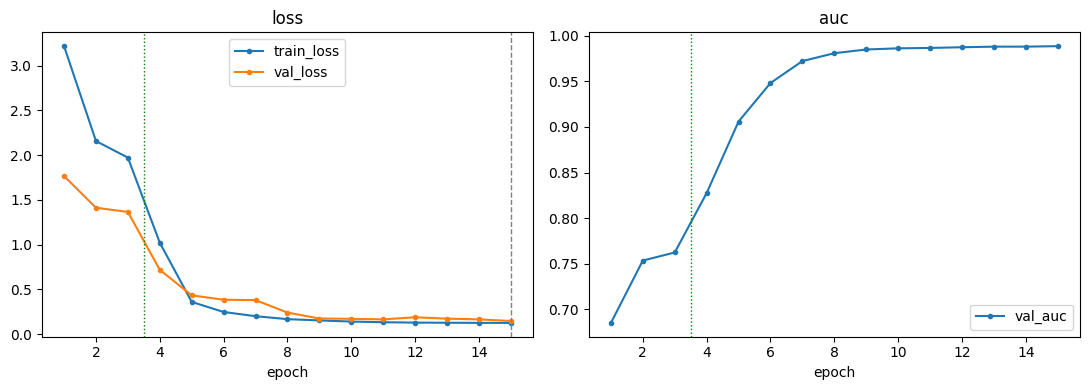

In [6]:
fig = V.plot_training_curves(history)
for ax in fig.axes:
    ax.axvline(STAGE1_EPOCHS + 0.5, color="green", ls=":", lw=1)   # stage boundary
fig.savefig(dirs["figures"] / f"training_curves_{BACKBONE}.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 - In-distribution evaluation (ai-real-images test)

Load the best EMA weights; report metrics at 0.5 and at a val-tuned threshold; save figures.

[efficientnet_b0] tuned threshold (on val): 0.1797


,threshold,n,n_fake,n_real,accuracy,f1_macro,precision,recall,auc_roc,pr_auc,mcc,brier
0,0.5,11963,5977,5986,0.957369,0.957362,0.968145,0.945792,0.990109,0.990052,0.914979,0.034209


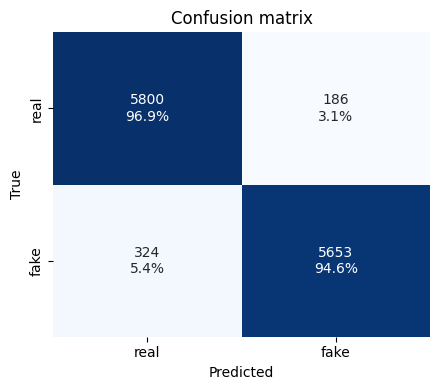

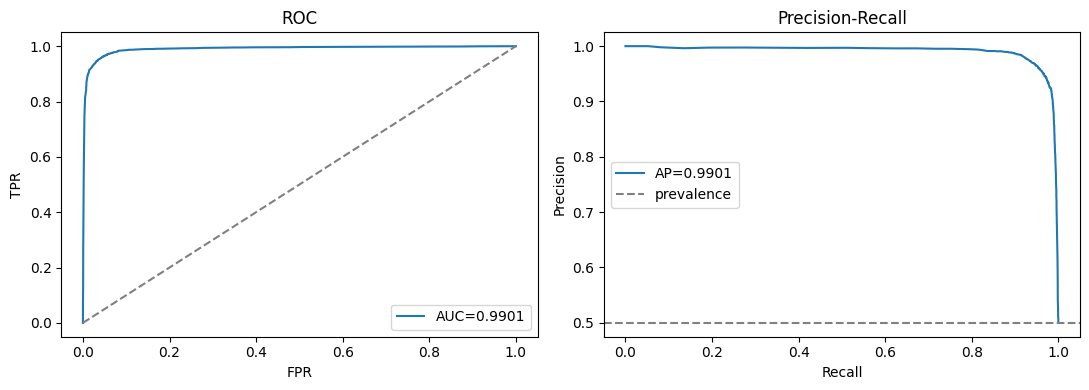

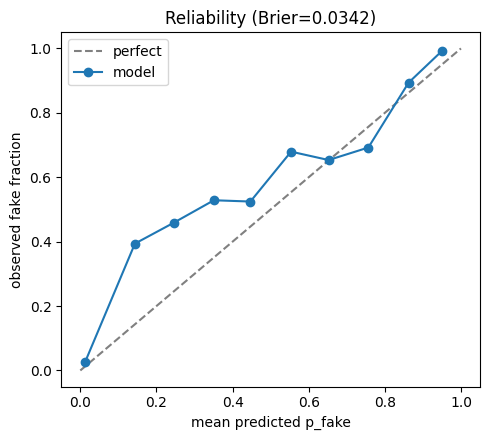

In [7]:
T.load_weights(ckpt_path, model, map_location=device)   # loads the saved EMA weights
yt, pt, _ = T.evaluate(model, test_loader, device)
yv, pv, _ = T.evaluate(model, val_loader, device)
tuned = Me.best_f1_threshold(yv, pv)
m05 = Me.classification_metrics(yt, pt, threshold=0.5)
mtuned = Me.classification_metrics(yt, pt, threshold=tuned["threshold"])
print(f"[{BACKBONE}] tuned threshold (on val):", round(tuned["threshold"], 4))
display(Me.summary_table(m05))

V.plot_confusion(m05["confusion_matrix"]).savefig(dirs["figures"] / f"confusion_{BACKBONE}.png", dpi=150, bbox_inches="tight")
V.plot_roc_pr(yt, pt).savefig(dirs["figures"] / f"roc_pr_{BACKBONE}.png", dpi=150, bbox_inches="tight")
V.plot_reliability(yt, pt).savefig(dirs["figures"] / f"reliability_{BACKBONE}.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 - Cross-generator (OOD) preview — tiny-genimage

,generator,accuracy,n
0,adm,0.556200,5000
1,biggan,0.438800,5000
2,glide,0.556000,5000
3,midjourney,0.763153,4999
4,sdv5,0.592919,4999
5,vqdm,0.399400,5000
6,wukong,0.645200,5000


overall OOD accuracy: 0.5645  (in-dist test acc: 0.9574)


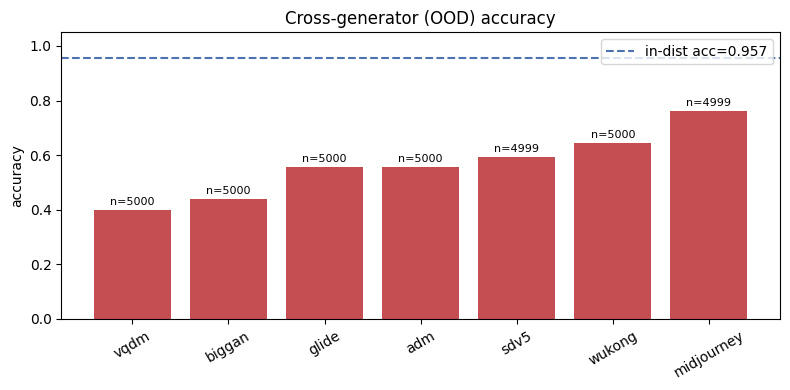

In [8]:
GEN_MAP = {
    "imagenet_ai_0419_biggan": "biggan", "imagenet_ai_0419_vqdm": "vqdm",
    "imagenet_ai_0424_sdv5": "sdv5", "imagenet_ai_0424_wukong": "wukong",
    "imagenet_ai_0508_adm": "adm", "imagenet_glide": "glide", "imagenet_midjourney": "midjourney",
}
ood_loader, ood_df = D.make_ood_loader(TINY_MANIFEST, WORKING_SIZE, BATCH_SIZE, mean, std, num_workers=NUM_WORKERS)
yo, po, _ = T.evaluate(model, ood_loader, device)
ood_df = ood_df.assign(p_fake=po, y_true=yo)
ood_df["y_pred"] = (ood_df["p_fake"] >= 0.5).astype(int)
ood_df["generator"] = ood_df["source"].map(GEN_MAP).fillna(ood_df["source"])
rows = [{"generator": gen, "accuracy": float((g["y_pred"] == g["y_true"]).mean()), "n": int(len(g))}
        for gen, g in ood_df.groupby("generator")]
per_gen = pd.DataFrame(rows)
overall_ood = float((ood_df["y_pred"] == ood_df["y_true"]).mean())
display(per_gen)
print(f"overall OOD accuracy: {overall_ood:.4f}  (in-dist test acc: {m05['accuracy']:.4f})")
V.plot_per_generator_bar(per_gen, ref_acc=m05["accuracy"]).savefig(dirs["figures"] / f"ood_per_generator_{BACKBONE}.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 - Explainability (Grad-CAM)

Target layer depends on the backbone: ResNet50 → `layer4[-1]`; EfficientNet-B0 → `conv_head`.

C:\Users\user\AppData\Local\Temp\ipykernel_14248\3872830330.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  xt = eval_tf(torch.from_numpy(arr).permute(2, 0, 1))


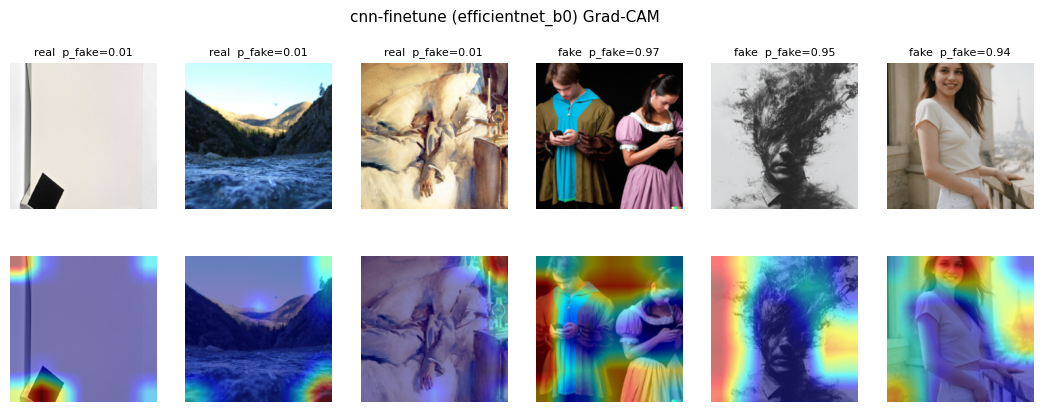

In [9]:
eval_tf = D.build_eval_tf(WORKING_SIZE, mean, std)
target_layers = [model.layer4[-1]] if "resnet" in BACKBONE else [model.conv_head]
examples = E.pick_examples(test_df, n_per_class=3, seed=0)
fig, axes = plt.subplots(2, len(examples), figsize=(2.2 * len(examples), 4.6))
model.eval()
for j, ex in enumerate(examples):
    arr = eda.read_rgb(ex["filepath"])
    xt = eval_tf(torch.from_numpy(arr).permute(2, 0, 1))
    x = xt.unsqueeze(0).to(device)
    rgb = D.denormalize(xt, mean, std).permute(1, 2, 0).numpy()
    with torch.no_grad():
        p = torch.sigmoid(model(x)).item()
    overlay = E.gradcam_overlay(model, target_layers, x, rgb)
    axes[0, j].imshow(rgb); axes[0, j].axis("off"); axes[0, j].set_title(f"{ex['label']}  p_fake={p:.2f}", fontsize=8)
    axes[1, j].imshow(overlay); axes[1, j].axis("off")
fig.suptitle(f"cnn-finetune ({BACKBONE}) Grad-CAM", fontsize=11)
fig.savefig(dirs["figures"] / f"gradcam_{BACKBONE}.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 - Save metrics (per backbone)

In [10]:
record = {
    "pipeline": PIPELINE,
    "backbone": BACKBONE,
    "created": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "working_size": WORKING_SIZE,
    "normalization": NORM,
    "dataset": {"in_distribution": "ai-real-images", "ood": "tiny-genimage"},
    "threshold_default": 0.5,
    "threshold_tuned": tuned["threshold"],
    "in_distribution": {"at_0.5": m05, "at_tuned": mtuned},
    "ood": {
        "overall_accuracy": overall_ood,
        "per_generator": {r.generator: {"accuracy": r.accuracy, "n": r.n} for r in per_gen.itertuples()},
        "preview": True,
    },
    "train_history": {
        "epochs": len(history["val_auc"]),
        "stage1_epochs": STAGE1_EPOCHS,
        "best_epoch": int(np.argmax(history["val_auc"])) + 1,
        "best_val_auc": float(max(history["val_auc"])),
    },
    "figures": {k: f"figures/{k}_{BACKBONE}.png" for k in ["training_curves", "confusion", "roc_pr", "reliability", "ood_per_generator", "gradcam"]},
}
Me.save_metrics(record, dirs["metrics"] / f"metrics_{BACKBONE}.json")
print("saved", dirs["metrics"] / f"metrics_{BACKBONE}.json")
print("\n[{bb}] in-dist @0.5:  acc {accuracy:.4f}  f1 {f1_macro:.4f}  auc {auc_roc:.4f}  mcc {mcc:.4f}  brier {brier:.4f}".format(bb=BACKBONE, **m05))

saved C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\artifacts\cnn-finetune\metrics\metrics_efficientnet_b0.json

[efficientnet_b0] in-dist @0.5:  acc 0.9574  f1 0.9574  auc 0.9901  mcc 0.9150  brier 0.0342


**Now set `BACKBONE = "resnet50"` in section 0 and run the notebook again to train the second backbone.**

**Next:** `07_vit-lora.ipynb` (designed in the next step).